# Chapter 16: Material and Information Delays

*Systems Thinking with AI* by Jason Karpeles

Two delays with the same mean behave differently, and where a delay sits matters as much as how long it is.

**Goal.** Four demonstrations of the chapter's two delays: a conveyor and a tank given the same step, a chain of tanks that walks the shape from one toward the other, a tank whose step size is pushed to its own mean, and both delays placed inside a correction loop.

**Demonstrations**

1. The conveyor and the tank
2. Chaining tanks walks toward the conveyor
3. A tank stepped at its own mean is a conveyor
4. The same delay inside a correction loop

The chapter's own model code is written out in full below, so the notebook runs with NumPy and Matplotlib alone. The interactive version of this chapter is at [https://karpeles.com/companions/systems-thinking-with-ai/16-delays/reader.html](https://karpeles.com/companions/systems-thinking-with-ai/16-delays/reader.html).

All example inputs are constructed teaching examples built from the chapter's own numbers.

## Setup

Imports, plus two small helpers: `%%module` runs a cell as a named module so the chapter files can import one another by their package names, and `show` draws a demonstration's figure and lists its values.

In [1]:
import os, sys, tempfile, types
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.core.magic import register_cell_magic
from IPython.display import Markdown, display

%matplotlib inline

WORKDIR = tempfile.mkdtemp(prefix="systems-thinking-")


@register_cell_magic
def module(line, cell):
    """Run a cell as a named module so the chapter code can import it by name."""
    name = line.strip()
    parts = name.split(".")
    for i in range(1, len(parts)):
        parent = ".".join(parts[:i])
        if parent not in sys.modules:
            pkg = types.ModuleType(parent)
            pkg.__path__ = []
            sys.modules[parent] = pkg
            if i > 1:
                setattr(sys.modules[".".join(parts[:i - 1])], parts[i - 1], pkg)
    mod = types.ModuleType(name)
    mod.__file__ = os.path.join(WORKDIR, *parts) + ".py"
    mod.__package__ = ".".join(parts[:-1])
    sys.modules[name] = mod
    if len(parts) > 1:
        setattr(sys.modules[".".join(parts[:-1])], parts[-1], mod)
    exec(compile(cell, name, "exec"), mod.__dict__)


def show(result):
    """Draw the figure, then list the calculated values and the reading."""
    fig, metrics, interpretation = result[:3]
    plt.show()
    display(Markdown("\n".join(f"- **{k}:** {v}" for k, v in metrics.items())))
    display(Markdown(interpretation))


def sweep(function, controls):
    """Recompute every setting offered in the interactive reader and list the values."""
    import itertools
    keys = [k for k, _ in controls]
    rows = []
    for combo in itertools.product(*[v for _, v in controls]):
        fig, metrics, _ = function(**dict(zip(keys, combo)))[:3]
        plt.close(fig)
        setting = ", ".join(f"{k} = {v}" for k, v in zip(keys, combo))
        rows.append(f"- **{setting}**: " + "; ".join(f"{k} {v}" for k, v in metrics.items()))
    display(Markdown("\n".join(rows)))


## The chapter's model code

Each cell below is one file of the chapter's code, defined under its package name. Later chapters build on earlier ones, so some files come from the chapters they cite.

`chapters/chapter_16_delays/code/validate_number.py`

In [2]:
%%module chapters.chapter_16_delays.code.validate_number
import math


def validate_number(value: float, name: str) -> None:
    """Reject non-numeric or non-finite values used by the teaching functions."""
    if type(value) not in (int, float) or not math.isfinite(float(value)):
        raise ValueError(f"{name} must be a finite number")


`chapters/chapter_16_delays/code/delays.py`

In [3]:
%%module chapters.chapter_16_delays.code.delays
"""Two delays with the same mean and different behavior."""

from collections import deque

from .validate_number import validate_number


class PipelineDelay:
    """A conveyor. What goes in comes out intact, exactly `length` periods later."""

    def __init__(self, length: int, initial: float = 0.0) -> None:
        if type(length) is not int or length < 1:
            raise ValueError("length must be a positive whole number of periods")
        validate_number(initial, "initial")
        self.length = length
        self.line: deque[float] = deque([float(initial)] * length, maxlen=length)

    def step(self, inflow: float) -> float:
        validate_number(inflow, "inflow")
        out = self.line[0]
        self.line.append(inflow)
        return out

    def in_transit(self) -> float:
        return sum(self.line)


class FirstOrderDelay:
    """A well-stirred tank. Output is proportional to what is currently held."""

    def __init__(self, mean: float, initial_rate: float = 0.0) -> None:
        validate_number(mean, "mean")
        if mean <= 0:
            raise ValueError("mean delay must be positive")
        validate_number(initial_rate, "initial_rate")
        self.mean = mean
        self.held = float(initial_rate) * mean

    def step(self, inflow: float, dt: float = 1.0) -> float:
        validate_number(inflow, "inflow")
        if dt <= 0:
            raise ValueError("dt must be positive")
        out = self.held / self.mean
        self.held += dt * (inflow - out)
        return out

    def in_transit(self) -> float:
        return self.held


def run_pipeline(inflows: list[float], length: int, initial: float = 0.0) -> list[float]:
    """Feed a series through a pipeline and return what emerges."""
    delay = PipelineDelay(length, initial)
    return [delay.step(x) for x in inflows]


def run_first_order(inflows: list[float], mean: float, initial_rate: float = 0.0) -> list[float]:
    """Feed a series through a first-order delay and return its output."""
    delay = FirstOrderDelay(mean, initial_rate)
    return [delay.step(x) for x in inflows]


def time_to_fraction(outflows: list[float], target: float, fraction: float) -> int | None:
    """First period where the output reaches a fraction of its eventual level."""
    if not 0.0 < fraction <= 1.0:
        raise ValueError("fraction must lie in (0, 1]")
    for i, value in enumerate(outflows):
        if value >= fraction * target:
            return i
    return None


Formatting and plotting helpers used by the demonstrations (`readerkit`).

In [4]:
%%module readerkit
"""Formatting and plotting helpers shared by the demonstrations."""
from __future__ import annotations

import math

# Restrained palette with good contrast on white. Use direct labels, not
# colour alone, to distinguish series.
PALETTE = {
    "ink": "#172a3b",
    "teal": "#136f75",
    "gold": "#8f5d0f",
    "navy": "#334c72",
    "terracotta": "#a24a33",
    "olive": "#5d6a37",
    "grey": "#6b757b",
    "light": "#c9d3d6",
}

FONT_SIZE = 11.5
SMALL_FONT = 10.5


def new_figure(ncols=1, width=None, height=4.3):
    """Return (fig, axes) with constrained layout and the house size.

    One panel is 6.6 x 4.3 inches; two panels are 10.4 x 4.3 inches. At the
    reader's display width this keeps 11 to 12 point text legible.
    """
    import matplotlib.pyplot as plt

    if width is None:
        width = 6.6 if ncols == 1 else 10.4
    fig, axes = plt.subplots(1, ncols, figsize=(width, height), layout="constrained")
    for ax in (axes if ncols > 1 else [axes]):
        ax.grid(alpha=0.18)
    return fig, axes


def fmt(value, digits=2):
    """Format a finite number with a fixed number of decimals.

    Returns the string "undefined" for None. Raises ValueError for NaN or
    infinity, because a reader must be told why a value is undefined; use
    ``undefined(reason)`` for that.
    """
    if value is None:
        return "undefined"
    value = float(value)
    if not math.isfinite(value):
        raise ValueError("non-finite value; state why it is undefined with undefined(reason)")
    text = f"{value:.{digits}f}"
    if text.startswith("-") and float(text) == 0:
        text = text[1:]
    return text


def signed(value, digits=2):
    """Format a number for use inside a written calculation: negatives get parentheses."""
    text = fmt(value, digits)
    return f"({text})" if text.startswith("-") else text


def undefined(reason):
    """Display string for a quantity that has no value in this state."""
    return f"undefined ({reason})"


def is_tie(a, b, tol=1e-9):
    return abs(float(a) - float(b)) <= tol


def argmax_set(scores, tol=1e-9):
    """Names whose score is within tol of the maximum. ``scores`` is a dict."""
    best = max(scores.values())
    return [name for name, value in scores.items() if abs(value - best) <= tol]


def label_point(ax, x, y, text, color=None, dx=6, dy=6, ha="left", va="bottom", size=None):
    """Directly label a point with an offset in points (no arrow)."""
    return ax.annotate(
        text,
        (x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        ha=ha,
        va=va,
        color=color or PALETTE["ink"],
        fontsize=size or SMALL_FONT,
    )


## Demonstration functions

Each function below runs the chapter's model for one demonstration and returns a figure, the calculated values and a worked reading of them.

In [5]:
"""Chapter 16 reader: the conveyor and the tank.

Every delayed output comes from the Chapter 16 pack (PipelineDelay, FirstOrderDelay,
run_pipeline, run_first_order, time_to_fraction).
"""
from __future__ import annotations

import numpy as np
from readerkit import PALETTE, fmt, label_point, new_figure, signed, undefined

from chapters.chapter_16_delays.code.delays import (
    FirstOrderDelay,
    PipelineDelay,
    run_first_order,
    run_pipeline,
    time_to_fraction,
)

EQ_PIPELINE = "pipeline    = run_pipeline(step, length=4)"
EQ_TANK = "first_order = run_first_order(step, mean=4.0)"
EQ_STEP = "step = [0.0] * 3 + [10.0] * 40"


# Demonstration 1: the same step through a conveyor and a tank of the same mean.

def conveyor_and_tank(delay=4, height=10.0):
    step = [0.0] * 3 + [float(height)] * 40
    pipeline = run_pipeline(step, length=int(delay))
    tank = run_first_order(step, mean=float(delay))
    periods = np.arange(len(step))
    shown = 26

    fig, ax = new_figure()
    ax.step(periods[:shown], step[:shown], where="post", color=PALETTE["grey"], linestyle="dotted", linewidth=1.5)
    ax.step(periods[:shown], pipeline[:shown], where="post", color=PALETTE["navy"], linewidth=2.4)
    ax.plot(periods[:shown], tank[:shown], color=PALETTE["terracotta"], marker="o", markersize=4, linewidth=2)
    label_point(ax, 0.3, height, "Step in", color=PALETTE["grey"], dx=0, dy=5)
    label_point(ax, 25, pipeline[25] * 0.5, "Pipeline", color=PALETTE["navy"], dx=-4, dy=0, ha="right")
    label_point(ax, 25, tank[25], "Tank", color=PALETTE["terracotta"], dx=-4, dy=-18, ha="right", va="top")
    ax.set_xlim(0, 25.5)
    ax.set_ylim(-0.08 * height, 1.25 * height)
    ax.set_xlabel("Period")
    ax.set_ylabel("Outflow")

    def hit(series):
        index = time_to_fraction(series, float(height), 0.95)
        return fmt(index, 0) if index is not None else undefined("not reached in 43 periods")

    r = (delay - 1) / delay
    k5, k7 = 2, 4
    tank5 = height * (1 - r ** k5)
    tank7 = height * (1 - r ** k7)
    pipe7 = height if 7 - delay >= 3 else 0.0
    metrics = {
        "Pipeline at period 5": fmt(pipeline[5], 2),
        "Tank at period 5": fmt(tank[5], 2),
        "Pipeline at period 7": fmt(pipeline[7], 2),
        "Tank at period 7": fmt(tank[7], 2),
        "Period pipeline completes": fmt(3 + delay, 0),
        "Period tank first reaches 95 percent": hit(tank),
    }
    assert abs(tank5 - tank[5]) < 1e-9 and abs(tank7 - tank[7]) < 1e-9 and pipe7 == pipeline[7]
    rr = fmt(r, 3)
    interpretation = (
        f"The step starts at period 3. The pipeline repeats the input from {fmt(delay, 0)} periods earlier, so at "
        f"period 7 it shows the input of period {fmt(7 - delay, 0)}: {fmt(pipe7, 1)}. The tank releases 1/{fmt(delay, 0)} of "
        f"what it holds each period, which leaves a share {rr} behind. After 2 periods of input: "
        f"{fmt(height, 0)} x (1 - {rr} x {rr}) = {fmt(tank5, 2)}; after 4: "
        f"{fmt(height, 0)} x (1 - {' x '.join([rr] * 4)}) = {fmt(tank7, 2)}."
    )
    alt = (f"A step of {fmt(height, 0)} at period 3 through a pipeline of length {fmt(delay, 0)}, which jumps once "
           f"at period {fmt(3 + delay, 0)}, and a tank of mean {fmt(delay, 0)}, which rises at once and keeps "
           f"approaching {fmt(height, 0)}.")
    return fig, metrics, interpretation, alt


# Demonstration 2: chaining first-order stages walks the shape from tank toward conveyor.

def chained_stages(stages=1, total_mean=4.0):
    dt = 0.1
    n_steps = int(round(32 / dt))
    start = int(round(3 / dt))
    inflow = [0.0] * start + [10.0] * (n_steps - start)
    stage_mean = total_mean / stages
    units = [FirstOrderDelay(stage_mean) for _ in range(stages)]
    out = []
    for x in inflow:
        v = x
        for u in units:
            v = u.step(v, dt)
        out.append(v)
    conveyor = PipelineDelay(int(round(total_mean / dt)))
    belt = [conveyor.step(x) for x in inflow]
    times = np.arange(n_steps) * dt
    index = time_to_fraction(out, 10.0, 0.95)
    after = (index - start) * dt if index is not None else None
    belt_after = (time_to_fraction(belt, 10.0, 0.95) - start) * dt

    fig, ax = new_figure()
    ax.plot(times, belt, color=PALETTE["navy"], linestyle="dashed", linewidth=1.8)
    ax.plot(times, out, color=PALETTE["terracotta"], linewidth=2.4)
    label_point(ax, 31.5, 10, "Conveyor of the same mean", color=PALETTE["navy"], dx=0, dy=6, ha="right")
    label_point(ax, 31.5, out[-1], f"{fmt(stages, 0)} stage(s)", color=PALETTE["terracotta"], dx=0, dy=-8, ha="right", va="top")
    ax.set_xlim(0, 32)
    ax.set_ylim(-0.8, 12.5)
    ax.set_xlabel("Time")
    ax.set_ylabel("Outflow (step of 10 at time 3)")

    early = out[start + int(round(1.0 / dt))]
    metrics = {
        "Stages": fmt(stages, 0),
        "Mean of each stage": fmt(stage_mean, 2),
        "Output 1 time unit after the step": fmt(early, 2),
        "Time after the step to reach 95 percent": fmt(after, 1) if after is not None else undefined("not reached"),
        "Conveyor reaches 95 percent after": fmt(belt_after, 1),
    }
    interpretation = (
        f"{fmt(stages, 0)} stage(s) each of mean {fmt(total_mean, 1)}/{fmt(stages, 0)} = {fmt(stage_mean, 2)}, so the total mean is "
        f"{fmt(stages, 0)} x {fmt(stage_mean, 2)} = {fmt(stages * stage_mean, 1)}, the same as the conveyor's {fmt(total_mean, 1)}. "
        f"One time unit after the step the chain has released {fmt(early, 2)} of the 10, against 0.00 for the "
        f"conveyor. It reaches 95 percent {fmt(after, 1)} time units after the step, against {fmt(belt_after, 1)} for the conveyor."
    )
    alt = (f"A chain of {fmt(stages, 0)} first order stage(s) with total mean {fmt(total_mean, 1)} answering a step of 10, "
           f"drawn against a dashed conveyor of the same mean that jumps once.")
    return fig, metrics, interpretation, alt


# Demonstration 3: a tank stepped at its own mean stops being a tank.

def step_size(dt=4.0, mean=4.0):
    horizon = 24.0

    def run(h):
        tank = FirstOrderDelay(float(mean))
        n = int(round(horizon / h))
        return [(k * h, tank.step(10.0, h)) for k in range(n)]

    coarse = run(dt)
    fine = run(0.05)
    times = [t for t, _ in coarse]
    vals = [v for _, v in coarse]
    ft = [t for t, _ in fine]
    fv = [v for _, v in fine]

    fig, ax = new_figure()
    ax.plot(ft, fv, color=PALETTE["grey"], linewidth=1.6, linestyle="dashed")
    ax.plot(times, vals, color=PALETTE["terracotta"], marker="o", linewidth=2, markersize=6)
    label_point(ax, 23.5, 9.2, "Very small step (reference)", color=PALETTE["grey"], dx=0, dy=-20, ha="right", va="top")
    label_point(ax, 23.5, 10, "Chosen step", color=PALETTE["terracotta"], dx=0, dy=8, ha="right")
    ax.set_xlim(0, 24)
    ax.set_ylim(-0.6, 11.8)
    ax.set_xlabel("Time (a constant inflow of 10 starts at time 0)")
    ax.set_ylabel("Tank outflow")

    held1 = dt * 10.0
    err = None
    out1 = held1 / mean
    k8 = int(round(8.0 / dt))
    at8 = vals[k8]
    ref8 = fv[int(round(8.0 / 0.05))]
    share = dt / mean
    if abs(share - 1.0) < 1e-9:
        note = ("The step equals the mean, so the tank is emptied completely each step: the outflow jumps to the "
                "full inflow and stays there, which is a conveyor and not a tank.")
    else:
        note = "A step well below the mean releases a share of the tank each step and stays close to the reference."
    err = round(at8, 3) - round(ref8, 3)
    metrics = {
        "Share of the tank released per step (dt / mean)": fmt(share, 3),
        "First reading after the first update": fmt(out1, 3),
        "Outflow at time 8": fmt(at8, 3),
        "Outflow at time 8, very small step": fmt(ref8, 3),
        "Error at time 8": signed(err, 3),
    }
    interpretation = (
        f"One step: held = {fmt(dt, 2)} x 10 = {fmt(held1, 1)}, and the next reading is {fmt(held1, 1)}/{fmt(mean, 1)} = "
        f"{fmt(out1, 3)}. Share released per step = {fmt(dt, 2)}/{fmt(mean, 1)} = {fmt(share, 3)}. At time 8 the "
        f"chosen step gives {fmt(at8, 3)} against {fmt(ref8, 3)}, an error of {fmt(at8, 3)} - {fmt(ref8, 3)} = "
        f"{signed(err, 3)}. {note}"
    )
    alt = (f"Outflow of a tank of mean {fmt(mean, 1)} stepped every {fmt(dt, 2)} time units as dots, against a dashed "
           f"reference computed with a very small step.")
    return fig, metrics, interpretation, alt


# Demonstration 4: the same delay inside a correction loop.

def inside_the_loop(delay=2, gain=0.25):
    target, periods = 100.0, 24

    def run(kind):
        unit = PipelineDelay(int(delay)) if kind == "pipeline" else FirstOrderDelay(float(delay))
        x = 0.0
        path = [x]
        for _ in range(periods):
            seen = unit.step(x)
            x = x + gain * (target - seen)
            path.append(x)
        return path

    pipe = run("pipeline")
    tank = run("tank")
    xs = np.arange(periods + 1)
    high = max(max(pipe), max(tank), target)
    low = min(min(pipe), min(tank), 0.0)

    fig, ax = new_figure()
    ax.axhline(target, color=PALETTE["grey"], linestyle="dashed", linewidth=1.3)
    ax.plot(xs, pipe, color=PALETTE["navy"], linewidth=2.2)
    ax.plot(xs, tank, color=PALETTE["terracotta"], linewidth=2.2)
    span = high - low
    ax.set_ylim(low - 0.12 * span, high + 0.18 * span)
    label_point(ax, 0.3, target, "Target 100", color=PALETTE["grey"], dx=0, dy=-16, va="top")
    label_point(ax, 23.5, pipe[-1], "Pipeline", color=PALETTE["navy"], dx=-4, dy=8, ha="right")
    label_point(ax, 23.5, tank[-1], "Tank", color=PALETTE["terracotta"], dx=-4, dy=-10, ha="right", va="top")
    ax.set_xlim(0, 24)
    ax.set_xlabel("Period")
    ax.set_ylabel("Stock being corrected")

    def over(path):
        return max(path) - target

    def over_shown(path):
        return round(max(path), 1) - 100.0

    first = gain * target

    def phrase(name, path):
        o = over(path)
        if o <= 1e-9:
            return f"the {name} never crosses 100 (peak {fmt(max(path), 1)}), a tie with no overshoot"
        return f"the {name} peaks at {fmt(max(path), 1)}, so {fmt(max(path), 1)} - 100 = {fmt(over_shown(path), 1)} above the target"

    metrics = {
        "First correction": fmt(first, 1),
        "Pipeline peak": fmt(max(pipe), 1),
        "Tank peak": fmt(max(tank), 1),
        "Pipeline after 24 periods": fmt(pipe[-1], 1),
        "Tank after 24 periods": fmt(tank[-1], 1),
    }
    interpretation = (
        f"The first correction is {fmt(gain, 2)} x (100 - 0) = {fmt(first, 1)}, whatever the delay, because nothing "
        f"has reached the decider yet. With a delay of {fmt(delay, 0)}: {phrase('pipeline', pipe)}; "
        f"{phrase('tank', tank)}. Gain and delay multiply, and lowering either one damps the swing."
    )
    alt = (f"A stock corrected toward 100 by a rule with gain {fmt(gain, 2)} that reads it through a pipeline or a tank "
           f"of delay {fmt(delay, 0)}. The pipeline path peaks at {fmt(max(pipe), 1)} and the tank path at {fmt(max(tank), 1)}.")
    return fig, metrics, interpretation, alt


## 1. The conveyor and the tank

*Given the same mean delay, how differently do a pipeline and a first-order delay answer one step?*

The tank starts releasing the moment material enters, so it responds at once but finishes slowly. The pipeline shows nothing until the whole delay has passed and then shows everything.

    step = [0.0] * 3 + [10.0] * 40
    pipeline    = run_pipeline(step, length=4)
    first_order = run_first_order(step, mean=4.0)

**Symbols and inputs.** The input is nothing for 3 periods, then a constant step. A pipeline of length L repeats its input L periods later. A first-order delay of mean L releases 1/L of what it holds each period. Outflow is in the same units as the step.

**Predict first.** With a delay of 4, which is higher at period 5, the pipeline or the tank?

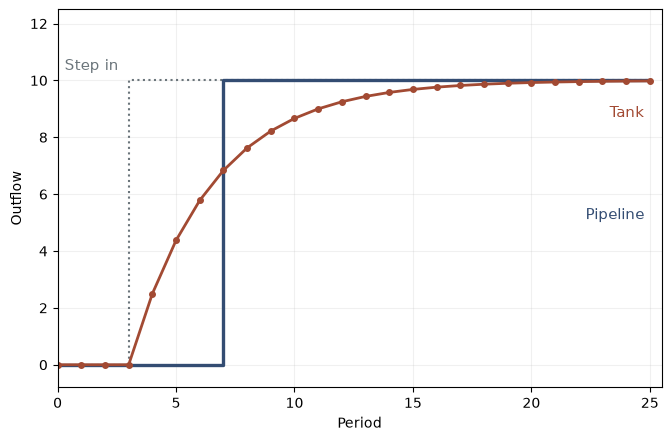

- **Pipeline at period 5:** 0.00
- **Tank at period 5:** 4.38
- **Pipeline at period 7:** 10.00
- **Tank at period 7:** 6.84
- **Period pipeline completes:** 7
- **Period tank first reaches 95 percent:** 14

The step starts at period 3. The pipeline repeats the input from 4 periods earlier, so at period 7 it shows the input of period 3: 10.0. The tank releases 1/4 of what it holds each period, which leaves a share 0.750 behind. After 2 periods of input: 10 x (1 - 0.750 x 0.750) = 4.38; after 4: 10 x (1 - 0.750 x 0.750 x 0.750 x 0.750) = 6.84.

In [6]:
show(conveyor_and_tank(delay=4, height=10.0))

**Use the idea.** Ask whether everything that entered together leaves together. If yes, use a pipeline; if it mixes, use a tank.

**Where the conclusion applies.** Step input, one-period steps, empty at the start. A real delay may sit between these two shapes, and a pipeline is exact only if every item truly takes the same time.

*Constructed example: the chapter's own step of 10 through delays of length and mean 4, with other lengths defined for this reader.*

Every setting the interactive reader offers for this demonstration:

In [7]:
sweep(conveyor_and_tank, [('delay', [2, 4, 6, 8]), ('height', [10.0, 20.0])])

- **delay = 2, height = 10.0**: Pipeline at period 5 10.00; Tank at period 5 7.50; Pipeline at period 7 10.00; Tank at period 7 9.38; Period pipeline completes 5; Period tank first reaches 95 percent 8
- **delay = 2, height = 20.0**: Pipeline at period 5 20.00; Tank at period 5 15.00; Pipeline at period 7 20.00; Tank at period 7 18.75; Period pipeline completes 5; Period tank first reaches 95 percent 8
- **delay = 4, height = 10.0**: Pipeline at period 5 0.00; Tank at period 5 4.38; Pipeline at period 7 10.00; Tank at period 7 6.84; Period pipeline completes 7; Period tank first reaches 95 percent 14
- **delay = 4, height = 20.0**: Pipeline at period 5 0.00; Tank at period 5 8.75; Pipeline at period 7 20.00; Tank at period 7 13.67; Period pipeline completes 7; Period tank first reaches 95 percent 14
- **delay = 6, height = 10.0**: Pipeline at period 5 0.00; Tank at period 5 3.06; Pipeline at period 7 0.00; Tank at period 7 5.18; Period pipeline completes 9; Period tank first reaches 95 percent 20
- **delay = 6, height = 20.0**: Pipeline at period 5 0.00; Tank at period 5 6.11; Pipeline at period 7 0.00; Tank at period 7 10.35; Period pipeline completes 9; Period tank first reaches 95 percent 20
- **delay = 8, height = 10.0**: Pipeline at period 5 0.00; Tank at period 5 2.34; Pipeline at period 7 0.00; Tank at period 7 4.14; Period pipeline completes 11; Period tank first reaches 95 percent 26
- **delay = 8, height = 20.0**: Pipeline at period 5 0.00; Tank at period 5 4.69; Pipeline at period 7 0.00; Tank at period 7 8.28; Period pipeline completes 11; Period tank first reaches 95 percent 26

## 2. Chaining tanks walks toward the conveyor

*If one tank is too spread out and a pipeline is too sharp, what do several tanks in a row do?*

Material has to cross the first tank before it reaches the second, so the immediate response disappears. Adding stages pulls the finish closer to the conveyor's sharp completion.

    first_order = run_first_order(step, mean=4.0)
    pipeline    = run_pipeline(step, length=4)

**Symbols and inputs.** A chain splits a total mean into equal stage means, so n stages of mean (total/n) are joined end to end. A very small time step of 0.1 keeps every stage accurate. Time is in the same unit as the mean.

**Predict first.** Going from one stage to four with the same total mean of 4, does the output one time unit after the step go up or down?

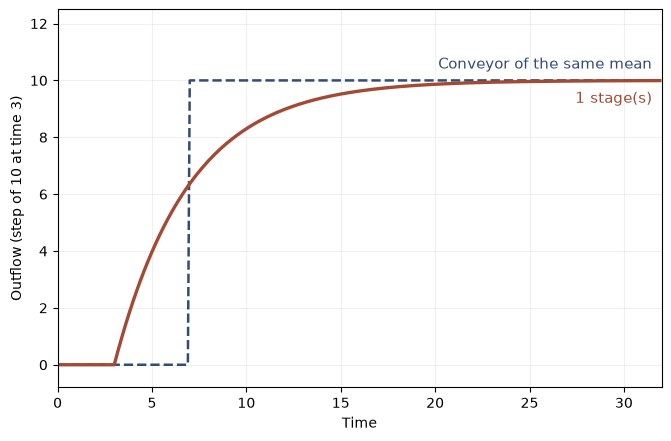

- **Stages:** 1
- **Mean of each stage:** 4.00
- **Output 1 time unit after the step:** 2.24
- **Time after the step to reach 95 percent:** 11.9
- **Conveyor reaches 95 percent after:** 4.0

1 stage(s) each of mean 4.0/1 = 4.00, so the total mean is 1 x 4.00 = 4.0, the same as the conveyor's 4.0. One time unit after the step the chain has released 2.24 of the 10, against 0.00 for the conveyor. It reaches 95 percent 11.9 time units after the step, against 4.0 for the conveyor.

In [8]:
show(chained_stages(stages=1, total_mean=4.0))

**Use the idea.** A recruitment process is sourcing, screening, offer and notice, not one tank. Choose the order from the mechanism, not the convenience.

**Where the conclusion applies.** Equal stage means and a total mean fixed in advance. The order of a delay is a modelling choice that needs a conversation with someone who knows the process, because this reader cannot supply it.

*Constructed example: stage counts and total means defined for this reader, computed with the chapter's FirstOrderDelay and PipelineDelay.*

Every setting the interactive reader offers for this demonstration:

In [9]:
sweep(chained_stages, [('stages', [1, 2, 4, 8]), ('total_mean', [4.0, 8.0])])

- **stages = 1, total_mean = 4.0**: Stages 1; Mean of each stage 4.00; Output 1 time unit after the step 2.24; Time after the step to reach 95 percent 11.9; Conveyor reaches 95 percent after 4.0
- **stages = 1, total_mean = 8.0**: Stages 1; Mean of each stage 8.00; Output 1 time unit after the step 1.18; Time after the step to reach 95 percent 23.9; Conveyor reaches 95 percent after 8.0
- **stages = 2, total_mean = 4.0**: Stages 2; Mean of each stage 2.00; Output 1 time unit after the step 0.86; Time after the step to reach 95 percent 9.3; Conveyor reaches 95 percent after 4.0
- **stages = 2, total_mean = 8.0**: Stages 2; Mean of each stage 4.00; Output 1 time unit after the step 0.25; Time after the step to reach 95 percent 18.8; Conveyor reaches 95 percent after 8.0
- **stages = 4, total_mean = 4.0**: Stages 4; Mean of each stage 1.00; Output 1 time unit after the step 0.13; Time after the step to reach 95 percent 7.6; Conveyor reaches 95 percent after 4.0
- **stages = 4, total_mean = 8.0**: Stages 4; Mean of each stage 2.00; Output 1 time unit after the step 0.01; Time after the step to reach 95 percent 15.3; Conveyor reaches 95 percent after 8.0
- **stages = 8, total_mean = 4.0**: Stages 8; Mean of each stage 0.50; Output 1 time unit after the step 0.00; Time after the step to reach 95 percent 6.3; Conveyor reaches 95 percent after 4.0
- **stages = 8, total_mean = 8.0**: Stages 8; Mean of each stage 1.00; Output 1 time unit after the step 0.00; Time after the step to reach 95 percent 12.9; Conveyor reaches 95 percent after 8.0

## 3. A tank stepped at its own mean is a conveyor

*What happens to a first-order delay when the model's step is as long as its mean?*

A step of dt moves dt/mean of the tank's content at once. At dt = mean that share is 1, so the whole tank empties each step, which is not an approximation of anything.

    first_order = run_first_order(step, mean=4.0)

**Symbols and inputs.** dt is the model's step, mean is the tank's mean delay, both in the same time unit. The tank holds an amount and releases held/mean per unit time. The inflow is a constant 10.

**Predict first.** With a mean of 4 and a step of 4, what is the outflow at the second reading?

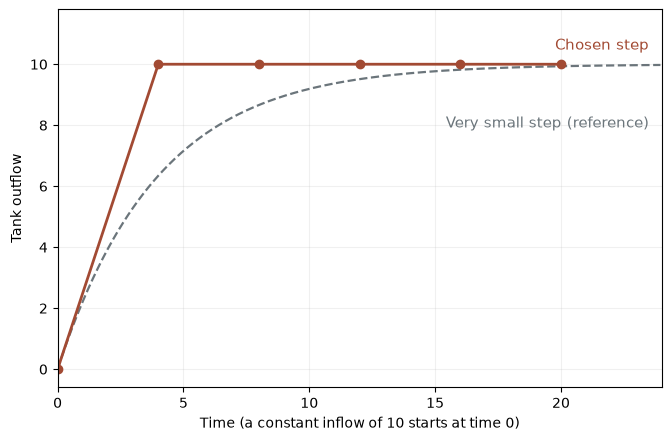

- **Share of the tank released per step (dt / mean):** 1.000
- **First reading after the first update:** 10.000
- **Outflow at time 8:** 10.000
- **Outflow at time 8, very small step:** 8.664
- **Error at time 8:** 1.336

One step: held = 4.00 x 10 = 40.0, and the next reading is 40.0/4.0 = 10.000. Share released per step = 4.00/4.0 = 1.000. At time 8 the chosen step gives 10.000 against 8.664, an error of 10.000 - 8.664 = 1.336. The step equals the mean, so the tank is emptied completely each step: the outflow jumps to the full inflow and stays there, which is a conveyor and not a tank.

In [10]:
show(step_size(dt=4.0, mean=4.0))

**Use the idea.** Halve the step and rerun. If the answer moves, the earlier results were partly arithmetic.

**Where the conclusion applies.** A constant inflow and a very small step as the reference. The chapter's rule of thumb is a step several times smaller than the shortest delay; here a share of 1.0 breaks it outright.

*Constructed example: the chapter's warning about a tank stepped at its own mean, run with the chapter's FirstOrderDelay.*

Every setting the interactive reader offers for this demonstration:

In [11]:
sweep(step_size, [('dt', [4.0, 2.0, 1.0, 0.5]), ('mean', [4.0, 8.0])])

- **dt = 4.0, mean = 4.0**: Share of the tank released per step (dt / mean) 1.000; First reading after the first update 10.000; Outflow at time 8 10.000; Outflow at time 8, very small step 8.664; Error at time 8 1.336
- **dt = 4.0, mean = 8.0**: Share of the tank released per step (dt / mean) 0.500; First reading after the first update 5.000; Outflow at time 8 7.500; Outflow at time 8, very small step 6.333; Error at time 8 1.167
- **dt = 2.0, mean = 4.0**: Share of the tank released per step (dt / mean) 0.500; First reading after the first update 5.000; Outflow at time 8 9.375; Outflow at time 8, very small step 8.664; Error at time 8 0.711
- **dt = 2.0, mean = 8.0**: Share of the tank released per step (dt / mean) 0.250; First reading after the first update 2.500; Outflow at time 8 6.836; Outflow at time 8, very small step 6.333; Error at time 8 0.503
- **dt = 1.0, mean = 4.0**: Share of the tank released per step (dt / mean) 0.250; First reading after the first update 2.500; Outflow at time 8 8.999; Outflow at time 8, very small step 8.664; Error at time 8 0.335
- **dt = 1.0, mean = 8.0**: Share of the tank released per step (dt / mean) 0.125; First reading after the first update 1.250; Outflow at time 8 6.564; Outflow at time 8, very small step 6.333; Error at time 8 0.231
- **dt = 0.5, mean = 4.0**: Share of the tank released per step (dt / mean) 0.125; First reading after the first update 1.250; Outflow at time 8 8.819; Outflow at time 8, very small step 8.664; Error at time 8 0.155
- **dt = 0.5, mean = 8.0**: Share of the tank released per step (dt / mean) 0.062; First reading after the first update 0.625; Outflow at time 8 6.439; Outflow at time 8, very small step 6.333; Error at time 8 0.106

## 4. The same delay inside a correction loop

*What does a delay do when the decider corrects against a value that has already moved?*

A long delay lets the stock keep moving while the decider still sees the old value, so the correction keeps pushing and overshoots. A lower gain damps the same swing without touching the delay.

    pipeline    = run_pipeline(step, length=4)
    first_order = run_first_order(step, mean=4.0)

**Symbols and inputs.** The stock starts at 0 with a target of 100. Each period the correction is gain x (100 - what the decider sees). What is seen is the stock read through a delay of the chosen length.

**Predict first.** At gain 0.25, does a delay of 4 overshoot 100 more than a delay of 1?

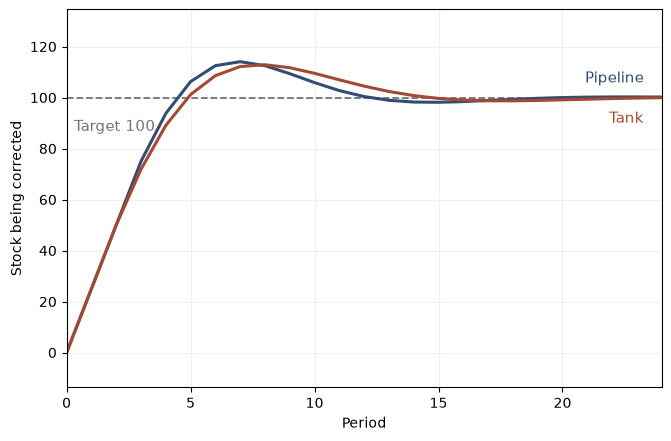

- **First correction:** 25.0
- **Pipeline peak:** 114.1
- **Tank peak:** 112.9
- **Pipeline after 24 periods:** 100.2
- **Tank after 24 periods:** 100.0

The first correction is 0.25 x (100 - 0) = 25.0, whatever the delay, because nothing has reached the decider yet. With a delay of 2: the pipeline peaks at 114.1, so 114.1 - 100 = 14.1 above the target; the tank peaks at 112.9, so 112.9 - 100 = 12.9 above the target. Gain and delay multiply, and lowering either one damps the swing.

In [12]:
show(inside_the_loop(delay=2, gain=0.25))

**Use the idea.** Enumerate the loops, then check which delays lie on them. A delay outside every loop only shifts and smooths.

**Where the conclusion applies.** A single balancing loop with a pipeline or tank delay on the reading. The delays here are in a loop; the same delay outside it would change when a number is seen but not the behaviour.

*Constructed example: a loop defined for this reader to illustrate the chapter's inside-the-loop argument, run with the chapter's two delays.*

Every setting the interactive reader offers for this demonstration:

In [13]:
sweep(inside_the_loop, [('delay', [1, 2, 4]), ('gain', [0.1, 0.25])])

- **delay = 1, gain = 0.1**: First correction 10.0; Pipeline peak 94.2; Tank peak 94.2; Pipeline after 24 periods 94.2; Tank after 24 periods 94.2
- **delay = 1, gain = 0.25**: First correction 25.0; Pipeline peak 100.0; Tank peak 100.0; Pipeline after 24 periods 100.0; Tank after 24 periods 100.0
- **delay = 2, gain = 0.1**: First correction 10.0; Pipeline peak 96.5; Tank peak 96.7; Pipeline after 24 periods 96.5; Tank after 24 periods 96.7
- **delay = 2, gain = 0.25**: First correction 25.0; Pipeline peak 114.1; Tank peak 112.9; Pipeline after 24 periods 100.2; Tank after 24 periods 100.0
- **delay = 4, gain = 0.1**: First correction 10.0; Pipeline peak 101.3; Tank peak 103.6; Pipeline after 24 periods 101.1; Tank after 24 periods 103.6
- **delay = 4, gain = 0.25**: First correction 25.0; Pipeline peak 162.5; Tank peak 141.1; Pipeline after 24 periods 99.6; Tank after 24 periods 90.5

## Exercises

Try each before opening the answer. The settings above let you check the numbers.

### Exercise 1

For a tank of mean 4 and a step of 10, what is the outflow two periods after the step starts?

<details><summary>Answer</summary>

The tank keeps 3/4 each period: 10 x (1 - 0.75 x 0.75) = 10 x 0.4375 = 4.375, which the chapter prints as 4.38.

</details>

### Exercise 2

A chain of 4 stages has a total mean of 8. What is each stage's mean?

<details><summary>Answer</summary>

8 / 4 = 2 per stage, and 4 x 2 = 8, so the total is unchanged.

</details>

### Exercise 3

With a mean of 8 and a step of 4, what share of the tank is released per step?

<details><summary>Answer</summary>

4 / 8 = 0.5 of the tank per step, so it stays a tank but a coarse one.

</details>

---

From *Systems Thinking with AI* by Jason Karpeles. Copyright Jason Karpeles. All rights reserved.

Interactive companion: https://karpeles.com/companions/systems-thinking-with-ai/